In [1]:
import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [6]:
df = pd.read_csv("balanced_reddit_posts_dataset2.csv")

In [7]:
texts = df["clean_text"].astype(str)
labels = df["category"]

label_mapping = {-1: 0, 0: 1, 1: 2}
y = df["category"].map(label_mapping).astype(int).values
num_labels = 3

In [29]:
le = LabelEncoder()
y = le.fit_transform(labels)
num_labels = len(le.classes_)

In [8]:
# DATA SPLIT (80-20 then 80-20 logic)
train_texts_full, test_texts, train_labels_full, test_labels = train_test_split(
    df["clean_text"].astype(str), y, test_size=0.2, random_state=42, stratify=y
)

# Inner split: 80% train, 20% validation (of the 80% training pool)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.2, random_state=42, stratify=train_labels_full
)

print(f"Training size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

Training size: 15840
Validation size: 3960
Test size: 4950


In [9]:
# TOKENIZATION (XLM-RoBERTa Base)
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [11]:
# GRID SEARCH CONFIGURATION
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [12]:
def run_experiment(batch_size, lr, epochs=10):
    print(f"\nRunning Experiment: batch={batch_size} | lr={lr}")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels
    )

    training_args = TrainingArguments(
        output_dir=f"./grid_xlmr_bs{batch_size}_lr{lr}",
        eval_strategy="epoch",
        save_strategy="epoch",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        fp16=True,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    metrics = trainer.evaluate()

    f1 = metrics["eval_f1"]
    loss = metrics["eval_loss"]

    # Memory cleanup
    del trainer, model
    torch.cuda.empty_cache()
    gc.collect()

    return f1, loss

In [ ]:
# Hyperparameter Grid
batch_sizes = [16, 32]
learning_rates = [2e-5, 3e-5, 5e-5]

results = []
best_f1 = 0
best_params = None

for bs in batch_sizes:
    for lr in learning_rates:
        f1, loss = run_experiment(bs, lr, epochs=10)
        results.append({
            "batch_size": bs,
            "learning_rate": lr,
            "loss": loss,
            "f1": f1
        })
        if f1 > best_f1:
            best_f1 = f1
            best_params = (bs, lr)

best_bs, best_lr = best_params
print(f"\nBEST CONFIG: {best_params} with F1: {round(best_f1, 4)}")


Running Experiment: batch=16 | lr=2e-05


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.463031,0.446431,0.844192,0.844036
2,0.314867,0.307046,0.902525,0.902330
3,0.241523,0.288197,0.914899,0.915048
4,0.208317,0.332779,0.917172,0.917235
5,0.105178,0.376452,0.923485,0.923502


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


BEST CONFIG: (16, 3e-05) with F1: 0.9239


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False)

print(results_df)

   batch_size  learning_rate      loss        f1
1          16        0.00003  0.276656  0.923861
3          32        0.00002  0.280584  0.920554
0          16        0.00002  0.288263  0.914795
4          32        0.00003  0.280452  0.914185
5          32        0.00005  0.289055  0.905500
2          16        0.00005  0.962852  0.420055


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
checkpoint_path = "/content/drive/MyDrive/checkpoint"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [24]:
training_args = TrainingArguments(
    output_dir="./evaluation",
    per_device_eval_batch_size=16,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics
)

In [25]:
# Evaluation and Plotting
pred_test = trainer.predict(test_dataset)
preds_test = np.argmax(pred_test.predictions, axis=1)

In [26]:
sentiment_names = ["negative", "neutral", "positive"]
print(classification_report(test_labels, preds_test, target_names=sentiment_names))

              precision    recall  f1-score   support

    negative       0.87      0.91      0.89      1650
     neutral       0.94      0.94      0.94      1650
    positive       0.91      0.87      0.89      1650

    accuracy                           0.91      4950
   macro avg       0.91      0.91      0.91      4950
weighted avg       0.91      0.91      0.91      4950



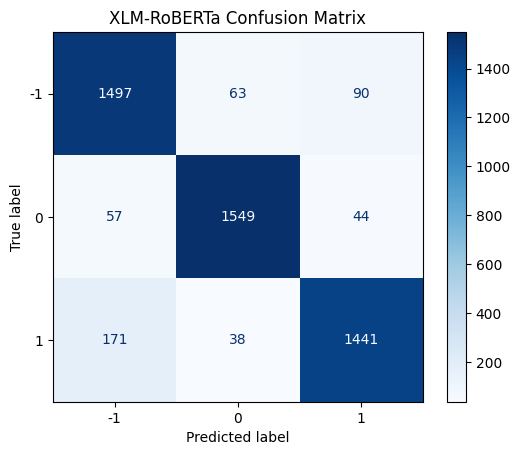

In [30]:
# Confusion Matrix
cm = confusion_matrix(test_labels, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("XLM-RoBERTa Confusion Matrix")
plt.show()

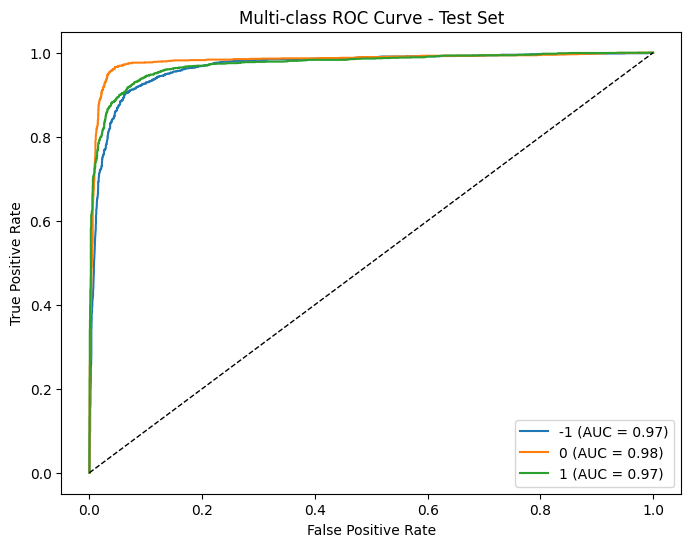

In [31]:
y_test_bin = label_binarize(test_labels, classes=range(num_labels))
y_score = pred_test.predictions

plt.figure(figsize=(8,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()